/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Saved artifact at '/tmp/tmpai831x2s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor_20')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  138738239570576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738239571344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738239570768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738241158224: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



===== RESULTS =====
Accuracy Before Quantization : 0.9773
Accuracy After Quantization  : 0.9777

Model Size Before : 1215.39 KB
Model Size After  : 106.22 KB


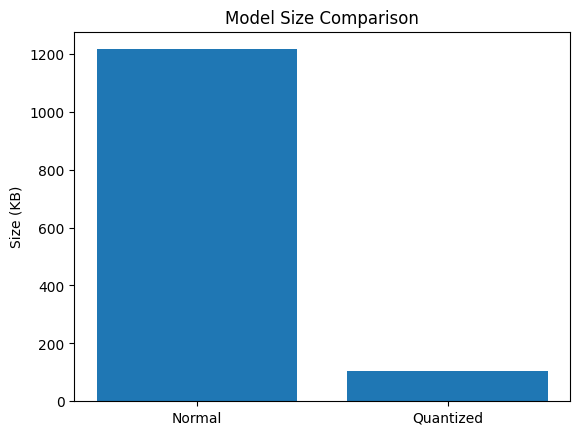

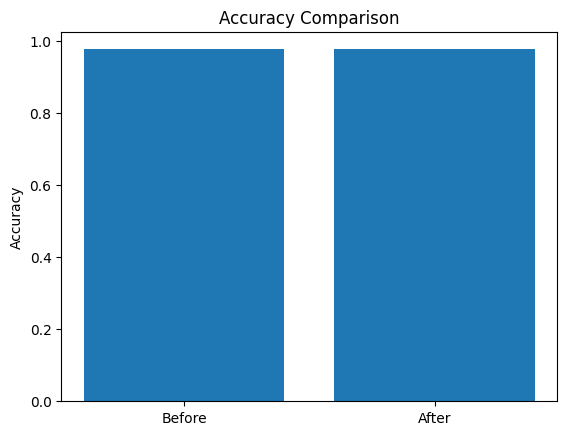

In [6]:
# -------- QUANTIZATION ----------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------ LOAD DATA ------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# ------------------ BUILD MODEL ------------------
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(x_train, y_train, epochs=5, verbose=0)

# ------------------ BEFORE QUANTIZATION ------------------
model.save("normal_mnist.h5")
size_before = os.path.getsize("normal_mnist.h5") / 1024

_, acc_before = model.evaluate(x_test, y_test, verbose=0)

# ------------------ QUANTIZATION ------------------
def representative_data():
    for i in range(100):
        yield [np.expand_dims(x_train[i], axis=0).astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

quant_model = converter.convert()

# Save quantized model
with open("quantized_mnist.tflite", "wb") as f:
    f.write(quant_model)

size_after = os.path.getsize("quantized_mnist.tflite") / 1024

# ------------------ TFLITE INFERENCE ------------------
interpreter = tf.lite.Interpreter(model_path="quantized_mnist.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

correct = 0

for i in range(len(x_test)):
    input_data = np.expand_dims(x_test[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    pred = np.argmax(output)
    if pred == y_test[i]:
        correct += 1

acc_after = correct / len(x_test)

# ------------------ NUMERIC OUTPUT ------------------
print("\n===== RESULTS =====")
print("Accuracy Before Quantization :", round(acc_before, 4))
print("Accuracy After Quantization  :", round(acc_after, 4))

print("\nModel Size Before :", round(size_before, 2), "KB")
print("Model Size After  :", round(size_after, 2), "KB")

# ------------------ BAR GRAPH (SIZE) ------------------
plt.figure()
plt.bar(['Normal', 'Quantized'], [size_before, size_after])
plt.title("Model Size Comparison")
plt.ylabel("Size (KB)")
plt.show()
print("\n")
# ------------------ BAR GRAPH (ACCURACY) ------------------
plt.figure()
plt.bar(['Before', 'After'], [acc_before, acc_after])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
Accuracy Before : 0.9706
Accuracy After  : 0.5867

Compressed Size Before : 1056.84 KB
Compressed Size After  : 711.58 KB


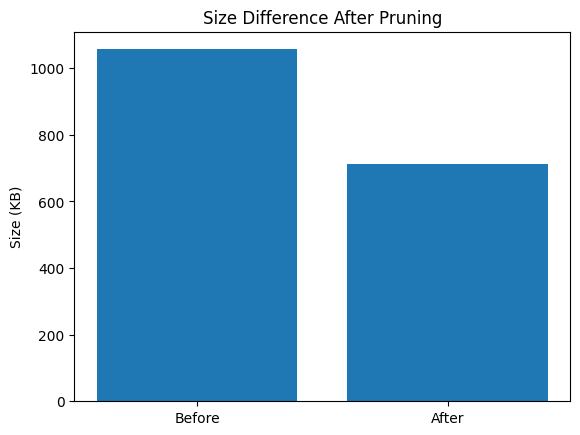

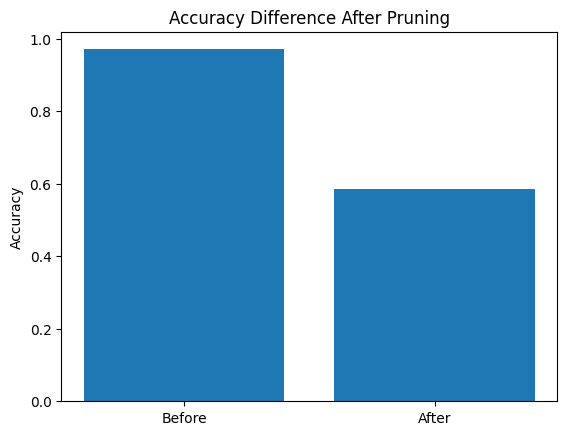

In [13]:
# -------- PRUNING ----------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

# -------- MODEL --------
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(x_train, y_train, epochs=3, verbose=0)

# -------- BEFORE PRUNING --------
model.save_weights("before.weights.h5")

with zipfile.ZipFile("before.zip", 'w', compression=zipfile.ZIP_DEFLATED) as z:
    z.write("before.weights.h5")

size_before = os.path.getsize("before.zip") / 1024
_, acc_before = model.evaluate(x_test, y_test, verbose=0)

# -------- STRONG PRUNING --------
weights = model.get_weights()

threshold = 0.2   # 🔥 increased threshold → more pruning

pruned_weights = []
for w in weights:
    pruned_w = np.where(np.abs(w) < threshold, 0, w)
    pruned_weights.append(pruned_w)

model.set_weights(pruned_weights)

# -------- AFTER PRUNING --------
model.save_weights("after.weights.h5")

with zipfile.ZipFile("after.zip", 'w', compression=zipfile.ZIP_DEFLATED) as z:
    z.write("after.weights.h5")

size_after = os.path.getsize("after.zip") / 1024
_, prune_acc = model.evaluate(x_test, y_test, verbose=0)

# -------- RESULTS --------
print("\n===== RESULTS =====")
print("Accuracy Before :", round(acc_before, 4))
print("Accuracy After  :", round(prune_acc, 4))

print("\nCompressed Size Before :", round(size_before, 2), "KB")
print("Compressed Size After  :", round(size_after, 2), "KB")

# -------- GRAPH (SIZE) --------
plt.figure()
plt.bar(['Before', 'After'], [size_before, size_after])
plt.title("Size Difference After Pruning")
plt.ylabel("Size (KB)")
plt.show()
print("\n")

# -------- GRAPH (ACCURACY) --------
plt.figure()
plt.bar(['Before', 'After'], [acc_before, prune_acc])
plt.title("Accuracy Difference After Pruning")
plt.ylabel("Accuracy")
plt.show()